In [1]:
import os, sys
current_dir = os.path.abspath('')
repo_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'reproduction', '2ABT_behaviour_models_updated'))
if repo_path not in sys.path:
    sys.path.append(repo_path)
from model_policies import log_likelihood_model_policy
import plot_models_v_mouse as pmm
import conditional_probs as cp
import model_simulations as sim
    
phase_3_path = os.path.abspath(os.path.join('..', 'phase 3'))
if phase_3_path not in sys.path:
    sys.path.append(phase_3_path)
from nonlinear_stickiness_refined_v2 import (
    run_rflr_nonlinear_stickiness,
    run_hmm_nonlinear_stickiness,
    run_hmm_reset_nonlinear_stickiness,
    run_hmm_resetv2_nonlinear_stickiness,
    run_fq_nonlinear_stickiness,
    run_fq_value_gated_only
)

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from scipy.optimize import minimize
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from collections import deque
import matplotlib.lines as mlines

In [2]:
data_path = os.path.join(repo_path, "mouse_data.csv")
df = pd.read_csv(data_path)
cv_results = pd.read_csv(os.path.join('..', "phase2_generative", "cv_results_fitted.csv"))

In [6]:
def extract_sessions(df, condition):
    """
    Extracts sessions for a specific condition.
    Returns:
        sessions: List of (choices, rewards) tuples for model fitting
        targets: List of true target states (0/1) for simulations
    """
    subset = df[df["Condition"] == condition]
    sessions_list = []
    targets_list = []
    
    for sess_id, group in subset.groupby("Session"):
        # Sort by trial
        group = group.sort_values("Trial")
        
        c = group["Decision"].astype(int).values
        r = group["Reward"].astype(int).values
        state = group["Target"].astype(int).values
        
        sessions_list.append((c, r))
        targets_list.append(state)
        
    return sessions_list, targets_list

In [5]:
def optimize_fold(model_type, train_sess, fixed_params):
    # Standard biological working-memory window for motor/value models
    n_steps_list = [1, 2, 3, 4, 5]
    
    # Expanded evidence-accumulation window for the cognitive model
    if model_type == "HMM_resetv2":
        n_steps_list = [1, 2, 3, 4, 5, 10, 15, 20]
        
    best_train_nll = np.inf
    best_params = None
    
    # Define bounds for (alpha_base, gamma)
    bounds = [(0.1, 5.0), (0.0, 5.0)] 

    for n in n_steps_list:
        # FQ_Value_Gated does not use gamma, so we fix it to 0.0
        if model_type == "FQ_Value_Gated":
            initial_guess = [1.5] # Only alpha_base
            fq_bounds = [(0.1, 5.0)]
            
            def objective(x):
                ab = x[0]
                # Pass 0.0 for gamma to maintain function signature compatibility
                ll = run_fq_value_gated_only(train_sess, (ab, fixed_params['k'], 1.0), n, 0.0, fit_mode=True, return_ll_only=True)
                return -ll
            
            res = minimize(objective, initial_guess, method='L-BFGS-B', bounds=fq_bounds)
            current_alpha, current_gamma = res.x[0], 0.0
        
        else:
            initial_guess = [1.5, 1.0] # alpha_base and gamma
            
            def objective(x):
                ab, g = x
                if model_type == "RFLR":
                    ll = run_rflr_nonlinear_stickiness(train_sess, (ab, fixed_params['beta'], fixed_params['tau']), n, g, fit_mode=True, return_ll_only=True)
                elif model_type == "HMM_sticky":
                    prms = {'q': fixed_params['q'], 'p': fixed_params['p'], 'alpha': ab, 'beta': fixed_params['beta'], 'tau': fixed_params['tau']}
                    ll = run_hmm_nonlinear_stickiness(train_sess, prms, n, g, fit_mode=True, return_ll_only=True)
                elif model_type == "HMM_reset":
                    prms = {'q': fixed_params['q'], 'p': fixed_params['p'], 'alpha': ab, 'beta': fixed_params['beta'], 'tau': fixed_params['tau']}
                    ll = run_hmm_reset_nonlinear_stickiness(train_sess, prms, n, g, fit_mode=True, return_ll_only=True)
                elif model_type == "HMM_resetv2":
                    prms = {'q': fixed_params['q'], 'p': fixed_params['p'], 'alpha': ab, 'beta': fixed_params['beta'], 'tau': fixed_params['tau']}
                    ll = run_hmm_resetv2_nonlinear_stickiness(train_sess, prms, n, g, fit_mode=True, return_ll_only=True)
                elif model_type == "FQ":
                    ll = run_fq_nonlinear_stickiness(train_sess, (ab, fixed_params['k'], 1.0), n, g, fit_mode=True, return_ll_only=True)
                elif model_type == "FQ_Value_Gated":
                    ll = run_fq_value_gated_only(train_sess, (ab, fixed_params['k'], 1.0), n, g, fit_mode=True, return_ll_only=True)

                return -ll

            res = minimize(objective, initial_guess, method='L-BFGS-B', bounds=bounds)
            current_alpha, current_gamma = res.x[0], res.x[1]

        if res.fun < best_train_nll:
            best_train_nll = res.fun
            best_params = {"alpha_base": current_alpha, "gamma": current_gamma, "n_steps": n}

    return best_params

In [6]:
def _process_fold(train_idx, test_idx, sessions, model_type, fixed_params):
    train_sess = [sessions[i] for i in train_idx]
    test_sess = [sessions[i] for i in test_idx]

    best_p = optimize_fold(model_type, train_sess, fixed_params)

    if model_type == "RFLR":
        ll = run_rflr_nonlinear_stickiness(
            test_sess, 
            (best_p["alpha_base"], fixed_params['beta'], fixed_params['tau']), 
            best_p["n_steps"], 
            best_p["gamma"], 
            fit_mode=True, 
            return_ll_only=True
        )
    elif model_type == "HMM_sticky":
        prms = {'q': fixed_params['q'], 'p': fixed_params['p'], 'alpha': best_p["alpha_base"], 
                'beta': fixed_params['beta'], 'tau': fixed_params['tau']}
        ll = run_hmm_nonlinear_stickiness(
            test_sess, prms, best_p["n_steps"], best_p["gamma"], 
            fit_mode=True, return_ll_only=True
        )
    elif model_type == "HMM_reset":
        prms = {'q': fixed_params['q'], 'p': fixed_params['p'], 'alpha': best_p["alpha_base"], 
                'beta': fixed_params['beta'], 'tau': fixed_params['tau']}
        ll = run_hmm_reset_nonlinear_stickiness(
            test_sess, prms, best_p["n_steps"], best_p["gamma"], 
            fit_mode=True, return_ll_only=True
        )
    elif model_type == "HMM_resetv2":
        prms = {'q': fixed_params['q'], 'p': fixed_params['p'], 'alpha': best_p["alpha_base"], 
                'beta': fixed_params['beta'], 'tau': fixed_params['tau']}
        ll = run_hmm_resetv2_nonlinear_stickiness(
            test_sess, prms, best_p["n_steps"], best_p["gamma"], 
            fit_mode=True, return_ll_only=True
        )
    elif model_type == "FQ":
        ll = run_fq_nonlinear_stickiness(
            test_sess, 
            (best_p["alpha_base"], fixed_params['k'], fixed_params['temp']), 
            best_p["n_steps"], 
            0.0, 
            fit_mode=True, 
            return_ll_only=True
        )
    elif model_type == "FQ_Value_Gated":
        # Note: gamma is passed as 0.0 for FQ compatibility
        ll = run_fq_value_gated_only(
            test_sess, 
            (best_p["alpha_base"], fixed_params['k'], fixed_params['temp']), 
            best_p["n_steps"], 
            0.0, 
            fit_mode=True, 
            return_ll_only=True
        )
    
    return {"ll": ll, "params": best_p}

In [7]:
def cross_validate_model(model_type, sessions, fixed_params, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    results = Parallel(n_jobs=-1)(
        delayed(_process_fold)(train_idx, test_idx, sessions, model_type, fixed_params)
        for train_idx, test_idx in kf.split(sessions)
    )

    test_lls = [res["ll"] for res in results]
    fold_params = [res["params"] for res in results]

    avg_alpha = np.mean([p["alpha_base"] for p in fold_params])
    std_alpha = np.std([p["alpha_base"] for p in fold_params])
    
    avg_gamma = np.mean([p["gamma"] for p in fold_params])
    std_gamma = np.std([p["gamma"] for p in fold_params])

    return {
        "Total_Test_LL": np.sum(test_lls),
        "Avg_Alpha": avg_alpha,
        "Std_Alpha": std_alpha,   # Add to return dictionary
        "Avg_Gamma": avg_gamma,
        "Std_Gamma": std_gamma,   # Add to return dictionary
        "Best_N_Steps": int(np.bincount([p["n_steps"] for p in fold_params]).argmax()) 
    }

In [8]:
def fit_condition_cv(condition):
    print(f"\n{'='*55}")
    print(f"--- Fitting Condition: {condition} (5-Fold CV) ---")
    print(f"{'='*55}")
    
    # 1. Data Preparation
    sessions, targets = extract_sessions(df, condition)
    total_trials = sum(len(c) for c, r in sessions)
    
    # Calculate HMM Hazard Rate (q) from block lengths
    est_p_switch = 1.0 / np.mean([len(t)/np.sum(np.abs(np.diff(t))) for t in targets])
    q_val = 1.0 - est_p_switch

    # 2. Extract Phase 2 "Hardware" Baselines (Fixed)
    beta_val = cv_results[cv_results["Condition"] == condition]["Beta"].mean()
    tau_val = cv_results[cv_results["Condition"] == condition]["Tau"].mean()
    k_val = 1 - np.exp(-1 / tau_val)
    p_val = int(condition.split("-")[0]) / 100.0

    r_params = {'beta': beta_val, 'tau': tau_val} 
    h_params = {'q': q_val, 'p': p_val, **r_params} 
    f_params = {'k': k_val, 'temp': 1.0}

    # 3. Parallel Optimization Execution
    print(f">> Dataset Size: {len(sessions)} sessions, {total_trials} total trials")
    
    results = {}
    
    model_configs = [
    ("RFLR", r_params),
    ("HMM_sticky", h_params),
    ("HMM_reset", h_params),  
    ("HMM_resetv2", h_params),  
    ("FQ", f_params),
    ("FQ_Value_Gated", f_params)
]

    for name, params in model_configs:
        print(f">> Optimizing {name} (Parallel)...")
        res = cross_validate_model(name, sessions, params)
        
        # Calculate Mean LL for Phase 2 comparison
        mLL = res['Total_Test_LL'] / total_trials
        
        print(f"{name:4} | Mean LL : {mLL:.4f}")
        print(f"{name:4} | Params  : a_base={res['Avg_Alpha']:.3f} (±{res['Std_Alpha']:.2f}), "
              f"gamma={res['Avg_Gamma']:.3f} (±{res['Std_Gamma']:.2f}), N={res['Best_N_Steps']}")
        print("-" * 30)
        
        results[name] = res

    return results

In [9]:
final_results_v2 = {}
for cond in ["80-20", "70-30"]:
    final_results_v2[cond] = fit_condition_cv(cond)


--- Fitting Condition: 80-20 (5-Fold CV) ---
>> Dataset Size: 159 sessions, 117334 total trials
>> Optimizing RFLR (Parallel)...
RFLR | Mean LL : -0.1804
RFLR | Params  : a_base=1.052 (±0.01), gamma=0.680 (±0.02), N=1
------------------------------
>> Optimizing HMM_sticky (Parallel)...
HMM_sticky | Mean LL : -0.2318
HMM_sticky | Params  : a_base=1.227 (±0.02), gamma=0.460 (±0.02), N=1
------------------------------
>> Optimizing HMM_reset (Parallel)...
HMM_reset | Mean LL : -0.1984
HMM_reset | Params  : a_base=0.606 (±0.01), gamma=0.883 (±0.01), N=1
------------------------------
>> Optimizing FQ_Value_Gated (Parallel)...
FQ_Value_Gated | Mean LL : -0.2204
FQ_Value_Gated | Params  : a_base=2.077 (±0.01), gamma=0.000 (±0.00), N=2
------------------------------

--- Fitting Condition: 70-30 (5-Fold CV) ---
>> Dataset Size: 200 sessions, 154872 total trials
>> Optimizing RFLR (Parallel)...
RFLR | Mean LL : -0.1959
RFLR | Params  : a_base=1.352 (±0.02), gamma=0.506 (±0.01), N=1
---------

In [26]:
data = [
    # ================= Condition: 80-20 =================
    ["80-20", "RFLR",           -0.1804, 1.052, 0.01, 0.680, 0.02, 1],
    ["80-20", "HMM_sticky",     -0.2318, 1.227, 0.02, 0.460, 0.02, 1],
    ["80-20", "HMM_reset",      -0.1984, 0.606, 0.01, 0.883, 0.01, 1],
    ["80-20", "HMM_resetv2",    -0.1832, 0.809, 0.01, 0.661, 0.01, 1],
    ["80-20", "FQ",             -0.2204, 2.076, 0.01, 0.002, 0.00, 2],
    ["80-20", "FQ_Value_Gated", -0.2204, 2.077, 0.01, 0.000, 0.00, 2],
    
    # ================= Condition: 70-30 =================
    ["70-30", "RFLR",           -0.1959, 1.352, 0.02, 0.506, 0.01, 1],
    ["70-30", "HMM_sticky",     -0.2447, 1.392, 0.02, 0.375, 0.01, 1],
    ["70-30", "HMM_reset",      -0.2094, 0.818, 0.01, 0.854, 0.01, 1],
    ["70-30", "HMM_resetv2",    -0.2015, 0.997, 0.01, 0.561, 0.01, 1],
    ["70-30", "FQ",             -0.2356, 1.702, 0.01, 0.548, 0.02, 2],
    ["70-30", "FQ_Value_Gated", -0.2278, 2.172, 0.01, 0.000, 0.00, 2],
]

columns = ["Condition", "Model", "Mean_LL", "Alpha_base", "Alpha_std", "Gamma", "Gamma_std", "N_steps"]
final_results = pd.DataFrame(data, columns=columns)

csv_filename = "phase4_final_model_comparison.csv"
final_results.to_csv(csv_filename, index=False)

print(f"Final results compiled and saved to '{csv_filename}'")
display(final_results)

Final results compiled and saved to 'phase4_final_model_comparison.csv'


,Condition,Model,Mean_LL,Alpha_base,Alpha_std,Gamma,Gamma_std,N_steps
0,80-20,RFLR,-0.1804,1.052,0.01,0.680,0.02,1
1,80-20,HMM_sticky,-0.2318,1.227,0.02,0.460,0.02,1
2,80-20,HMM_reset,-0.1984,0.606,0.01,0.883,0.01,1
3,80-20,HMM_resetv2,-0.1832,0.809,0.01,0.661,0.01,1
4,80-20,FQ,-0.2204,2.076,0.01,0.002,0.00,2
5,80-20,FQ_Value_Gated,-0.2204,2.077,0.01,0.000,0.00,2
6,70-30,RFLR,-0.1959,1.352,0.02,0.506,0.01,1
7,70-30,HMM_sticky,-0.2447,1.392,0.02,0.375,0.01,1
8,70-30,HMM_reset,-0.2094,0.818,0.01,0.854,0.01,1
9,70-30,HMM_resetv2,-0.2015,0.997,0.01,0.561,0.01,1


In [26]:
df_p4 = pd.read_csv("phase4_final_model_comparison.csv")
df_cv = pd.read_csv(os.path.join('..', "phase2_generative", "cv_results_fitted.csv"))
fig_dir = os.path.join("figures")
os.makedirs(fig_dir, exist_ok=True)

In [27]:
def simulate_agents(targets, p_reward, p_switch, alpha, beta, tau):
    """
    Runs 3 agents on the provided target sequences:
    1. RFLR Agent (using fitted params)
    2. Sticky HMM (using fitted RFLR params)
    3. Ideal HMM (Standard Thompson Sampling)
    """
    # 1. RFLR Agent (Generative)
    rflr_sessions = []
    gamma = np.exp(-1.0/tau)
    
    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        phi = 0
        c[0] = np.random.randint(2) # random start
        
        for t in range(1, T):
            # Recursive Belief Update
            prev_c = 2*c[t-1] - 1
            prev_r = r[t-1]
            phi = phi * gamma + beta * prev_r * prev_c
            psi = phi + alpha * prev_c
            
            # Stochastic Decision
            p_right = 1 / (1 + np.exp(-psi))
            c[t] = int(np.random.rand() < p_right)
            
            # Outcome (Probabilistic Reward)
            if c[t] == states[t]:
                r[t] = int(np.random.rand() < p_reward)
            else:
                r[t] = int(np.random.rand() < (1-p_reward))
        rflr_sessions.append((c, r))

    # 2. Sticky HMM 
    # Feed RFLR parameters directly. sim.BayesianMouse subtracts internal HMM bias.
    stickyHMM_params = {'p_switch': p_switch, 'p_reward': p_reward, 
                     'alpha': alpha, 'beta': beta, 'tau': tau}
    mouse_stickyHMM = sim.BayesianMouse(stickyHMM_params)
    stickyHMM_res = sim.simulate_experiment(stickyHMM_params, mouse_stickyHMM, targets, policy='stochastic', sticky=True)
    stickyHMM_sessions = [(np.array(x[0]), np.array(x[1])) for x in stickyHMM_res]

    # 3. Ideal HMM (Standard Thompson Sampling)
    idealHMM_params = {'p_switch': p_switch, 'p_reward': p_reward}
    mouse_idealHMM = sim.BayesianMouse(idealHMM_params)
    idealHMM_res = sim.simulate_experiment(idealHMM_params, mouse_idealHMM, targets, policy='thompson', sticky=False)
    idealHMM_sessions = [(np.array(x[0]), np.array(x[1])) for x in idealHMM_res]

    return rflr_sessions, stickyHMM_sessions, idealHMM_sessions

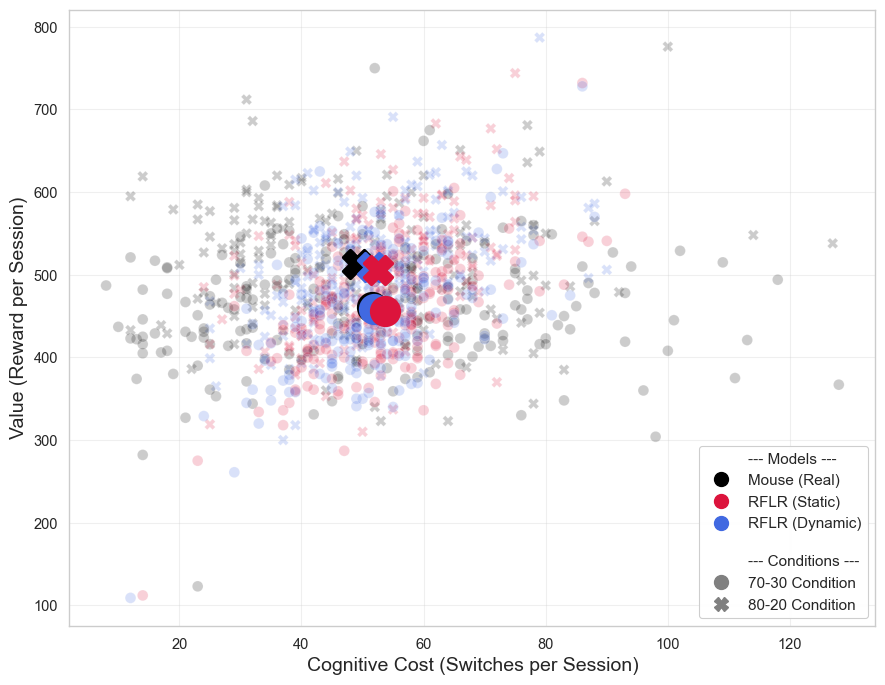

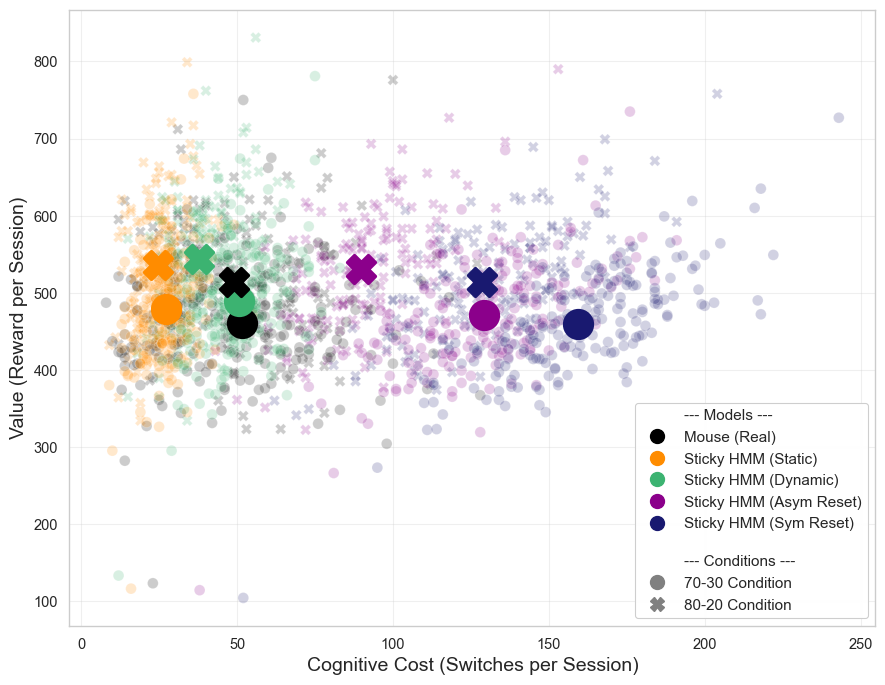

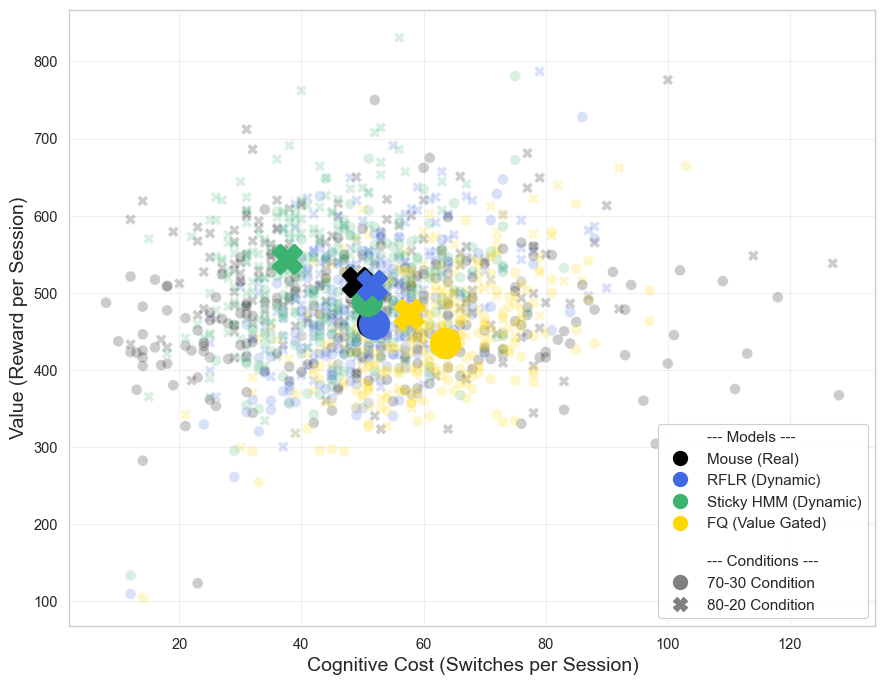

In [33]:

# =====================================================================
# 1. GENERATIVE SIMULATION FUNCTIONS (PHASE 4 CLOSED-LOOP)
# =====================================================================

def simulate_rflr_dynamic_generative(targets, p_reward, alpha_base, beta, tau, gamma_param, n_steps):
    gamma_decay = np.exp(-1.0 / tau)
    res_sessions = []
    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        phi = 0
        pe_buffer = deque([0.0] * n_steps, maxlen=n_steps)
        
        c[0] = np.random.randint(2)
        r[0] = int(np.random.rand() < p_reward) if c[0] == states[0] else int(np.random.rand() < (1-p_reward))
        prev_c_pm1 = 2*c[0] - 1
        phi = beta * r[0] * prev_c_pm1
        pe_buffer.append(float(r[0] - 0.5))

        for t in range(1, T):
            alpha_t = alpha_base * np.exp(gamma_param * (sum(pe_buffer) / len(pe_buffer)))
            psi = phi + alpha_t * prev_c_pm1
            c[t] = int(np.random.rand() < (1.0 / (1.0 + np.exp(-psi))))
            r[t] = int(np.random.rand() < p_reward) if c[t] == states[t] else int(np.random.rand() < (1-p_reward))
            
            curr_c_pm1 = 2*c[t] - 1
            phi = phi * gamma_decay + beta * r[t] * curr_c_pm1
            expected_r = 1.0 / (1.0 + np.exp(-(phi * curr_c_pm1)))
            pe_buffer.append(float(r[t] - expected_r))
            prev_c_pm1 = curr_c_pm1
        res_sessions.append((c, r))
    return res_sessions

def simulate_hmm_sticky_dynamic_generative(targets, p_reward, p_switch, alpha_base, beta, gamma_param, n_steps):
    res_sessions = []
    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        belief = 0.5  
        pe_buffer = deque([0.0] * n_steps, maxlen=n_steps)
        
        c[0] = np.random.randint(2)
        r[0] = int(np.random.rand() < p_reward) if c[0] == states[0] else int(np.random.rand() < (1-p_reward))
        prev_c_pm1 = 2*c[0] - 1
        pe_buffer.append(float(r[0] - 0.5))
        
        for t in range(1, T):
            belief = belief * (1 - p_switch) + (1 - belief) * p_switch
            alpha_t = alpha_base * np.exp(gamma_param * (sum(pe_buffer) / len(pe_buffer)))
            
            belief_clipped = max(min(belief, 1 - 1e-8), 1e-8)
            log_odds = np.log(belief_clipped / (1.0 - belief_clipped))
            psi = beta * log_odds + alpha_t * prev_c_pm1
            c[t] = int(np.random.rand() < (1.0 / (1.0 + np.exp(-psi))))
            
            r[t] = int(np.random.rand() < p_reward) if c[t] == states[t] else int(np.random.rand() < (1-p_reward))
            expected_r = belief * p_reward + (1 - belief) * (1 - p_reward) if c[t] == 1 else (1 - belief) * p_reward + belief * (1 - p_reward)
            pe_buffer.append(float(r[t] - expected_r))
            
            lik_1 = p_reward if (c[t]==1 and r[t]==1) or (c[t]==0 and r[t]==0) else (1 - p_reward)
            lik_0 = p_reward if (c[t]==0 and r[t]==1) or (c[t]==1 and r[t]==0) else (1 - p_reward)
            unnorm_1, unnorm_0 = belief * lik_1, (1 - belief) * lik_0
            belief = unnorm_1 / (unnorm_1 + unnorm_0)
            
            prev_c_pm1 = 2*c[t] - 1
        res_sessions.append((c, r))
    return res_sessions

def simulate_hmm_reset_generative(targets, p_reward, p_switch, alpha_base, beta, gamma_param, n_steps):
    res_sessions = []
    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        belief = 0.5
        pe_buffer = deque([0.0] * n_steps, maxlen=n_steps)
        
        c[0] = np.random.randint(2)
        r[0] = int(np.random.rand() < p_reward) if c[0] == states[0] else int(np.random.rand() < (1-p_reward))
        prev_c_pm1 = 2*c[0] - 1
        pe_buffer.append(float(r[0] - 0.5))
        
        for t in range(1, T):
            belief = belief * (1 - p_switch) + (1 - belief) * p_switch
            avg_pe = sum(pe_buffer) / len(pe_buffer)
            
            negative_surprise = abs(min(0, avg_pe))
            reset_strength = 1.0 - np.exp(-abs(gamma_param) * negative_surprise) 
            belief = belief * (1 - reset_strength) + 0.5 * reset_strength
            
            alpha_t = alpha_base * np.exp(gamma_param * avg_pe)
            
            belief_clipped = max(min(belief, 1 - 1e-8), 1e-8)
            log_odds = np.log(belief_clipped / (1.0 - belief_clipped))
            psi = beta * log_odds + alpha_t * prev_c_pm1
            c[t] = int(np.random.rand() < (1.0 / (1.0 + np.exp(-psi))))
            
            r[t] = int(np.random.rand() < p_reward) if c[t] == states[t] else int(np.random.rand() < (1-p_reward))
            expected_r = belief * p_reward + (1 - belief) * (1 - p_reward) if c[t] == 1 else (1 - belief) * p_reward + belief * (1 - p_reward)
            pe_buffer.append(float(r[t] - expected_r))
            
            lik_1 = p_reward if (c[t]==1 and r[t]==1) or (c[t]==0 and r[t]==0) else (1 - p_reward)
            lik_0 = p_reward if (c[t]==0 and r[t]==1) or (c[t]==1 and r[t]==0) else (1 - p_reward)
            belief = (belief * lik_1) / ((belief * lik_1) + ((1 - belief) * lik_0))
            
            prev_c_pm1 = 2*c[t] - 1
        res_sessions.append((c, r))
    return res_sessions

def simulate_hmm_reset_v2_generative(targets, p_reward, p_switch, alpha_base, beta, gamma_param, n_steps):
    res_sessions = []
    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        belief = 0.5
        pe_buffer = deque([0.0] * n_steps, maxlen=n_steps)
        
        c[0] = np.random.randint(2)
        r[0] = int(np.random.rand() < p_reward) if c[0] == states[0] else int(np.random.rand() < (1-p_reward))
        prev_c_pm1 = 2*c[0] - 1
        pe_buffer.append(float(r[0] - 0.5))
        
        for t in range(1, T):
            belief = belief * (1 - p_switch) + (1 - belief) * p_switch
            avg_pe = sum(pe_buffer) / len(pe_buffer)
            
            reset_strength = 1.0 - np.exp(-abs(gamma_param) * abs(avg_pe)) 
            belief = belief * (1 - reset_strength) + 0.5 * reset_strength
            
            alpha_t = alpha_base * np.exp(gamma_param * avg_pe)
            
            belief_clipped = max(min(belief, 1 - 1e-8), 1e-8)
            log_odds = np.log(belief_clipped / (1.0 - belief_clipped))
            psi = beta * log_odds + alpha_t * prev_c_pm1
            c[t] = int(np.random.rand() < (1.0 / (1.0 + np.exp(-psi))))
            
            r[t] = int(np.random.rand() < p_reward) if c[t] == states[t] else int(np.random.rand() < (1-p_reward))
            expected_r = belief * p_reward + (1 - belief) * (1 - p_reward) if c[t] == 1 else (1 - belief) * p_reward + belief * (1 - p_reward)
            pe_buffer.append(float(r[t] - expected_r))
            
            lik_1 = p_reward if (c[t]==1 and r[t]==1) or (c[t]==0 and r[t]==0) else (1 - p_reward)
            lik_0 = p_reward if (c[t]==0 and r[t]==1) or (c[t]==1 and r[t]==0) else (1 - p_reward)
            belief = (belief * lik_1) / ((belief * lik_1) + ((1 - belief) * lik_0))
            
            prev_c_pm1 = 2*c[t] - 1
        res_sessions.append((c, r))
    return res_sessions

def simulate_fq_value_gated_generative(targets, p_reward, alpha_base, beta, tau_val, n_steps):
    k_lr = 1.0 - np.exp(-1.0 / tau_val)
    res_sessions = []
    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        q_curr = np.array([0.5, 0.5]) 
        window_choices, window_rewards = [], []
        
        c[0] = np.random.randint(2)
        r[0] = int(np.random.rand() < p_reward) if c[0] == states[0] else int(np.random.rand() < (1-p_reward))
        window_choices.append(c[0]); window_rewards.append(r[0])
        prev_c_pm1 = 2*c[0] - 1
        
        for t in range(1, T):
            psi = beta * (q_curr[1] - q_curr[0]) + alpha_base * prev_c_pm1
            c[t] = int(np.random.rand() < (1.0 / (1.0 + np.exp(-psi))))
            r[t] = int(np.random.rand() < p_reward) if c[t] == states[t] else int(np.random.rand() < (1-p_reward))
            
            window_choices.append(c[t]); window_rewards.append(r[t])
            
            if len(window_rewards) >= n_steps or t == T - 1:
                for wc, wr in zip(window_choices, window_rewards):
                    q_curr[wc] += k_lr * (wr - q_curr[wc])
                window_choices, window_rewards = [], []
                
            prev_c_pm1 = 2*c[t] - 1
        res_sessions.append((c, r))
    return res_sessions

# =====================================================================
# 2. DATA AGGREGATION LOOP
# =====================================================================

simulated_data = []

for condition in ["80-20", "70-30"]:
    sessions, targets = extract_sessions(df, condition)
    p_high = int(condition.split("-")[0]) / 100.0
    
    beta_val = df_cv[df_cv["Condition"] == condition]["Beta"].mean()
    tau_val = df_cv[df_cv["Condition"] == condition]["Tau"].mean()
    alpha_static = df_cv[df_cv["Condition"] == condition]["Alpha"].mean()
    est_p_switch = 1.0 / np.mean([len(t)/np.sum(np.abs(np.diff(t))) for t in targets])
    
    def record(sess_list, label):
        for c, r in sess_list:
            simulated_data.append({
                "Condition": condition, "Model": label,
                "Switches": np.sum(np.abs(np.diff(c))), "Reward": np.sum(r)
            })

    record(sessions, "Mouse (Real)")

    r_static, s_static, _ = simulate_agents(targets, p_high, est_p_switch, alpha_static, beta_val, tau_val)
    record(r_static, "RFLR (Static)")
    record(s_static, "Sticky HMM (Static)")

    p = df_p4[(df_p4["Condition"]==condition) & (df_p4["Model"]=="RFLR")].iloc[0]
    rflr_dyn = simulate_rflr_dynamic_generative(targets, p_high, p["Alpha_base"], beta_val, tau_val, p["Gamma"], int(p["N_steps"]))
    record(rflr_dyn, "RFLR (Dynamic)")
    
    p = df_p4[(df_p4["Condition"]==condition) & (df_p4["Model"]=="HMM_sticky")].iloc[0]
    hmm_dyn = simulate_hmm_sticky_dynamic_generative(targets, p_high, est_p_switch, p["Alpha_base"], beta_val, p["Gamma"], int(p["N_steps"]))
    record(hmm_dyn, "Sticky HMM (Dynamic)")

    p = df_p4[(df_p4["Condition"]==condition) & (df_p4["Model"]=="HMM_reset")].iloc[0]
    hmm_reset = simulate_hmm_reset_generative(targets, p_high, est_p_switch, p["Alpha_base"], beta_val, p["Gamma"], int(p["N_steps"]))
    record(hmm_reset, "Sticky HMM (Asym Reset)")
    
    p = df_p4[(df_p4["Condition"]==condition) & (df_p4["Model"]=="HMM_resetv2")].iloc[0]
    hmm_resetv2 = simulate_hmm_reset_v2_generative(targets, p_high, est_p_switch, p["Alpha_base"], beta_val, p["Gamma"], int(p["N_steps"]))
    record(hmm_resetv2, "Sticky HMM (Sym Reset)")
    
    p = df_p4[(df_p4["Condition"]==condition) & (df_p4["Model"]=="FQ_Value_Gated")].iloc[0]
    fq_val = simulate_fq_value_gated_generative(targets, p_high, p["Alpha_base"], beta_val, tau_val, int(p["N_steps"]))
    record(fq_val, "FQ (Value Gated)")

df_simulated = pd.DataFrame(simulated_data)

# =====================================================================
# 3. INDIVIDUAL PLOTTING SCRIPT (3 Separate Figures)
# =====================================================================

# Redesigned, elegant color palette
model_colors = {
    "Mouse (Real)": "black",
    "RFLR (Static)": "crimson",
    "Sticky HMM (Static)": "darkorange",
    "RFLR (Dynamic)": "royalblue",
    "Sticky HMM (Dynamic)": "mediumseagreen",          
    "Sticky HMM (Asym Reset)": "darkmagenta",       
    "Sticky HMM (Sym Reset)": "midnightblue",       
    "FQ (Value Gated)": "gold"
}

condition_markers = {"70-30": "o", "80-20": "X"}

comparisons = [
    {
        "title": "Reward_vs_Cognitive_Cost: RFLR Static vs Dynamic",
        "models": ["Mouse (Real)", "RFLR (Static)", "RFLR (Dynamic)"]
    },
    {
        "title": "Reward_vs_Cognitive_Cost: HMM models comparison",
        "models": ["Mouse (Real)", "Sticky HMM (Static)", "Sticky HMM (Dynamic)", "Sticky HMM (Asym Reset)", "Sticky HMM (Sym Reset)"]
    },
    {
        "title": "Reward_vs_Cognitive_Cost: dynamic models comparison",
        "models": ["Mouse (Real)", "RFLR (Dynamic)", "Sticky HMM (Dynamic)", "FQ (Value Gated)"] 
    }
]

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

for comp in comparisons:
    fig, ax = plt.subplots(figsize=(9, 7))  # Creates a new individual plot
    df_plot = df_simulated[df_simulated["Model"].isin(comp["models"])]
    
    # Background individual session points
    sns.scatterplot(
        data=df_plot, x="Switches", y="Reward", hue="Model", style="Condition",
        palette=model_colors, markers=condition_markers, alpha=0.2, s=60, ax=ax, legend=False
    )
    
    # Emphasized Centroids
    centroids = df_plot.groupby(["Condition", "Model"])[["Switches", "Reward"]].mean().reset_index()
    for _, row in centroids.iterrows():
        ax.scatter(
            row["Switches"], row["Reward"], 
            s=400, color=model_colors[row["Model"]], marker=condition_markers[row["Condition"]], linewidth=2.5, zorder=10
        )

    ax.set_xlabel("Cognitive Cost (Switches per Session)", fontsize=14)
    ax.set_ylabel("Value (Reward per Session)", fontsize=14)
    ax.grid(True, alpha=0.3)

    # Isolated Legend
    legend_elements = [mlines.Line2D([], [], color='none', label='--- Models ---')]
    for model in comp["models"]:
        legend_elements.append(mlines.Line2D([], [], color=model_colors[model], marker='o', 
                                             linestyle='None', markersize=10, label=model))
    
    legend_elements.append(mlines.Line2D([], [], color='none', label='\n--- Conditions ---'))
    legend_elements.append(mlines.Line2D([], [], color='gray', marker='o', 
                                         linestyle='None', markersize=10, label='70-30 Condition'))
    legend_elements.append(mlines.Line2D([], [], color='gray', marker='X', 
                                         linestyle='None', markersize=10, label='80-20 Condition'))

    ax.legend(handles=legend_elements, loc='lower right', framealpha=0.95, fontsize=11)

    plt.tight_layout()
    safe_filename = comp["title"].replace(" ", "_").replace(":", "") + ".pdf"
    save_path = os.path.join(fig_dir, safe_filename)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()  # Displays the individual figure

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plot_models_v_mouse as pmm
import conditional_probs as cp
from nonlinear_stickiness_refined_v2 import run_rflr_nonlinear_stickiness

# ==========================================
# 1. 准备数据与参数
# ==========================================
condition_to_plot = "80-20" # 你可以改成 "70-30"
df_mouse = df[df['Condition'] == condition_to_plot].copy()

# 提取 Session 序列 (请确保 extract_sessions 已经定义在你的环境中)
sessions, targets = extract_sessions(df, condition_to_plot)

# 提取 RFLR (Dynamic) 的最优参数
beta_val = df_cv[df_cv["Condition"] == condition_to_plot]["Beta"].mean()
tau_val = df_cv[df_cv["Condition"] == condition_to_plot]["Tau"].mean()
p_dyn = df_p4[(df_p4["Condition"]==condition_to_plot) & (df_p4["Model"]=="RFLR")].iloc[0]

# ==========================================
# 2. 生成预测策略 (Predictive Policies)
# ==========================================
# 注意：fit_mode=True 强制 Agent 使用真实小鼠的历史数据来产生当前 trial 的概率
res = run_rflr_nonlinear_stickiness(
    sessions, 
    (p_dyn["Alpha_base"], beta_val, tau_val), 
    int(p_dyn["N_steps"]), 
    p_dyn["Gamma"], 
    fit_mode=True
)
policies = res["policies"] # 这是一个列表，每个元素是 shape 为 (T, 2) 的概率矩阵

# ==========================================
# 3. 将概率映射回 DataFrame 结构
# ==========================================
df_model = df_mouse.copy()

# 将所有 session 的预测概率展平为一维数组
p_right_all = np.concatenate([p[:, 1] for p in policies])
p_left_all = 1.0 - p_right_all

# 计算预期的 P(HighPort)
# 假设你的 DataFrame 中 'Target' 列指示了高奖励端 (1 为右，0 为左)
target_port = df_model['Target'].values 
df_model['highPort'] = np.where(target_port == 1, p_right_all, p_left_all)

# 计算预期的 P(Switch)
# 如果小鼠上一次选了右 (1)，它转换的概率就是模型预测选左的概率 (p_left_all)
prev_choice = df_model['Choice'].shift(1).fillna(0).values
df_model['Switch'] = np.where(prev_choice == 1, p_left_all, p_right_all)

# ==========================================
# 4. 绘制图表 (调用原作者的函数)
# ==========================================

# --- 图 1: 区组转换动态图 (Dynamics around block transitions) ---
bpos_mouse = pmm.get_block_position_summaries(df_mouse)
bpos_mouse['Model'] = 'Mouse'

bpos_model = pmm.get_block_position_summaries(df_model)
bpos_model['Model'] = 'RFLR (Dynamic)'

bpos_combined = pd.concat([bpos_mouse, bpos_model], ignore_index=True)

color_dict = {'Mouse': 'gray', 'RFLR (Dynamic)': 'royalblue'}
pmm.plot_by_block_position(bpos_combined, subset='Model', color_dict=color_dict)
plt.suptitle(f"Transition Dynamics: RFLR (Dynamic) [{condition_to_plot}]", y=1.05, fontweight='bold', fontsize=18)
plt.show()

# --- 图 2 & 图 3: 计算历史条件概率 ---
# cp.get_conditional_probs 会按照小鼠的真实历史分组，并对 'Switch' 列（这里已被我们替换为预测概率）求均值
df_hist_mouse = cp.get_conditional_probs(df_mouse, nback=3)
df_hist_model = cp.get_conditional_probs(df_model, nback=3)

# 图 2: History-Dependent P(Switch) 条形图
pmm.plot_sequences(
    df=df_hist_mouse, 
    overlay=df_hist_model, 
    main_label='Mouse', 
    overlay_label='RFLR (Dynamic)',
    title=f"History-Dependent P(switch) [{condition_to_plot}]"
)
plt.show()

# 图 3: 预期混淆矩阵 (Expected Confusion Matrix)
fig = pmm.plot_confusion(df_hist_mouse, df_hist_model, col='pswitch', color='Blues')
fig.suptitle(f"Expected Confusion Matrix [{condition_to_plot}]", fontweight='bold', y=1.1)
plt.show()

KeyError: 'Choice'